In [101]:
import numpy as np
import matplotlib.pyplot as plt
from tensorflow.keras.datasets import cifar10
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Flatten, Dense
from sklearn.metrics import classification_report, confusion_matrix
import seaborn as sns

In [102]:
# Load dataset
(X_train_full, y_train_full), (X_test_full, y_test_full) = cifar10.load_data()
y_train_full = y_train_full.flatten()
y_test_full = y_test_full.flatten()

# Define cat class
CAT_LABEL = 3

# Create binary labels
y_train = np.where(y_train_full == CAT_LABEL, 1, 0)
y_test = np.where(y_test_full == CAT_LABEL, 1, 0)

# Normalize images
X_train = X_train_full.astype("float32") / 255.0
X_test = X_test_full.astype("float32") / 255.0

In [103]:
model = Sequential([
    Flatten(input_shape=(32, 32, 3)),
    Dense(1, activation='sigmoid')  # Logistic regression output
])

model.compile(optimizer='adam', loss='binary_crossentropy', metrics=['accuracy'])

In [104]:
history = model.fit(X_train, y_train, epochs=10, batch_size=64, validation_split=0.1)

Epoch 1/10
704/704 [==============================] - 3s 3ms/step - loss: 0.3146 - accuracy: 0.8985 - val_loss: 0.3113 - val_accuracy: 0.8950
Epoch 2/10
704/704 [==============================] - 2s 3ms/step - loss: 0.3074 - accuracy: 0.8984 - val_loss: 0.3082 - val_accuracy: 0.8956
Epoch 3/10
704/704 [==============================] - 2s 3ms/step - loss: 0.3054 - accuracy: 0.8978 - val_loss: 0.3391 - val_accuracy: 0.8822
Epoch 4/10
704/704 [==============================] - 2s 3ms/step - loss: 0.3057 - accuracy: 0.8968 - val_loss: 0.3082 - val_accuracy: 0.8940
Epoch 5/10
704/704 [==============================] - 2s 3ms/step - loss: 0.3023 - accuracy: 0.8978 - val_loss: 0.3089 - val_accuracy: 0.8948
Epoch 6/10
704/704 [==============================] - 2s 3ms/step - loss: 0.3034 - accuracy: 0.8972 - val_loss: 0.3072 - val_accuracy: 0.8948
Epoch 7/10
704/704 [==============================] - 2s 3ms/step - loss: 0.3002 - accuracy: 0.8978 - val_loss: 0.3069 - val_accuracy: 0.8940
Epoch 

In [105]:
# Evaluate on test set
test_loss, test_accuracy = model.evaluate(X_test, y_test)
print(f"\n✅ Test Accuracy: {test_accuracy:.4f}")

313/313 [==============================] - 1s 3ms/step - loss: 0.3130 - accuracy: 0.8993

✅ Test Accuracy: 0.8993


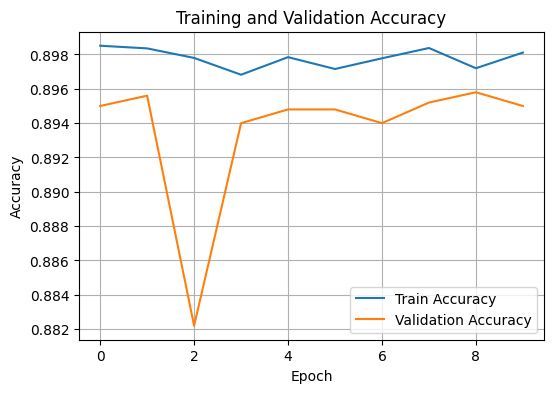

In [106]:
plt.figure(figsize=(6, 4))
plt.plot(history.history['accuracy'], label='Train Accuracy')
plt.plot(history.history['val_accuracy'], label='Validation Accuracy')
plt.title('Training and Validation Accuracy')
plt.xlabel('Epoch')
plt.ylabel('Accuracy')
plt.legend()
plt.grid(True)
plt.show()

1/1 [==============================] - 0s 93ms/step


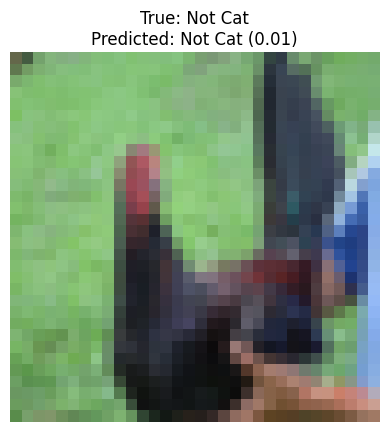

In [107]:
# Choose a test image
idx = 25
img = X_test[idx]
label = y_test[idx]

# Predict
img_input = np.expand_dims(img, axis=0)
prob = model.predict(img_input)[0][0]
pred = 1 if prob >= 0.5 else 0

# Show the image and prediction
plt.imshow(img)
plt.title(f"True: {'Cat' if label == 1 else 'Not Cat'}\nPredicted: {'Cat' if pred == 1 else 'Not Cat'} ({prob:.2f})")
plt.axis('off')
plt.show()

313/313 [==============================] - 1s 3ms/step


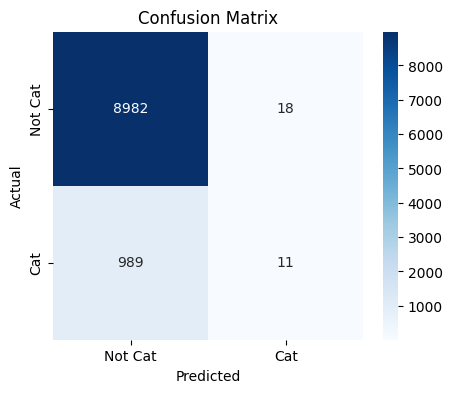


Classification Report:
              precision    recall  f1-score   support

     Not Cat       0.90      1.00      0.95      9000
         Cat       0.38      0.01      0.02      1000

    accuracy                           0.90     10000
   macro avg       0.64      0.50      0.48     10000
weighted avg       0.85      0.90      0.85     10000



In [108]:
y_pred = (model.predict(X_test) >= 0.5).astype(int)

# Confusion Matrix
cm = confusion_matrix(y_test, y_pred)
plt.figure(figsize=(5, 4))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', xticklabels=["Not Cat", "Cat"], yticklabels=["Not Cat", "Cat"])
plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.title("Confusion Matrix")
plt.show()

# Classification Report
print("\nClassification Report:")
print(classification_report(y_test, y_pred, target_names=["Not Cat", "Cat"]))

In [109]:
# Find an index where the true label is a cat (label = 3, converted to binary = 1)
cat_indices = np.where(y_test == 1)[0]
cat_index = cat_indices[0]  # you can change 0 to any number to test different cats

# Get image and label
img = X_test[cat_index]
true_label = y_test[cat_index]

In [110]:
# Preprocess input for prediction
img_input = np.expand_dims(img, axis=0)  # shape (1, 32, 32, 3)
prob = model.predict(img_input)[0][0]
pred_label = 1 if prob >= 0.5 else 0

1/1 [==============================] - 0s 41ms/step


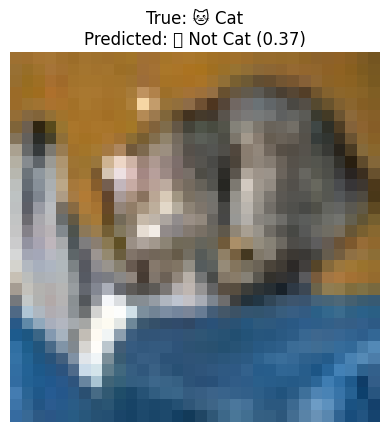

✅ Ground Truth: Cat
🧠 Model Prediction: Not Cat ❌
📊 Predicted Probability: 0.3710


In [111]:
import matplotlib.pyplot as plt

plt.imshow(img)
plt.axis('off')
plt.title(f"True: 🐱 Cat\nPredicted: {'🐱 Cat' if pred_label == 1 else '❌ Not Cat'} ({prob:.2f})")
plt.show()

# Print result in text
print("✅ Ground Truth: Cat")
print(f"🧠 Model Prediction: {'Cat 🐱' if pred_label == 1 else 'Not Cat ❌'}")
print(f"📊 Predicted Probability: {prob:.4f}")